In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import math, time
from torch import nn
import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from math import sqrt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
import random
import tensorflow as tf

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
ticker = "NVDA"
data = yf.Ticker(ticker)
stock_data = yf.download(ticker, start = '2000-01-01', end = None)
ds = stock_data[['Close']]
print(ds)


train_size = int(len(ds) * 0.70)
val_size = int(len(ds) * 0.15)
test_size = len(ds) - train_size - val_size



train_data = ds[:train_size]
val_data = ds[train_size:train_size+val_size]
test_data = ds[train_size+val_size:]

print("Train Data Size:", len(train_data))
print("Validation Data Size:", len(val_data))
print("Test Data Size:", len(test_data))


scaler= MinMaxScaler(feature_range=(0,1))
scaled_train_data = scaler.fit_transform(train_data)
scaled_test_data = scaler.transform(test_data)
scaled_val_data = scaler.transform(val_data)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price            Close
Ticker            NVDA
Date                  
2000-01-03    0.089431
2000-01-04    0.087044
2000-01-05    0.084178
2000-01-06    0.078685
2000-01-07    0.079999
...                ...
2025-04-08   96.300003
2025-04-09  114.330002
2025-04-10  107.570000
2025-04-11  110.930000
2025-04-14  110.589996

[6359 rows x 1 columns]
Train Data Size: 4451
Validation Data Size: 953
Test Data Size: 955


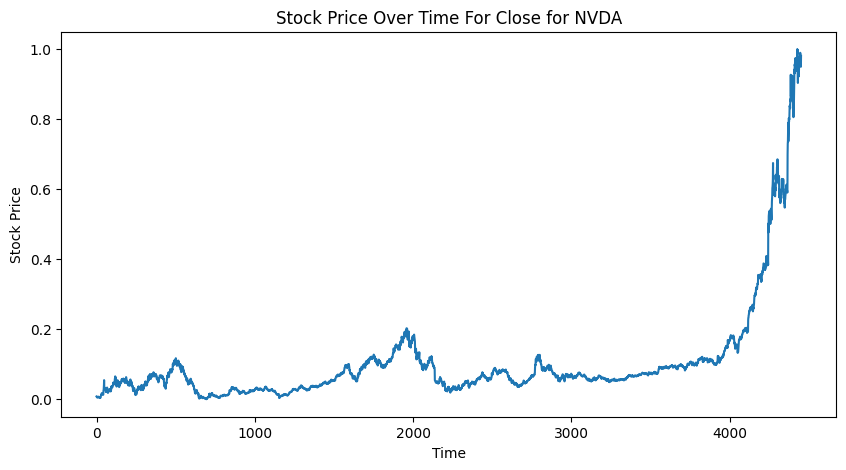

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(scaled_train_data)
plt.title(f'Stock Price Over Time For Close for {ticker}')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.show()

In [ ]:
def create_sequences(data, sequence_length):
  x = []
  y = []


  for i in range(len(data)- sequence_length):
    x.append(data[i:(i+sequence_length)])
    y.append(data[i+sequence_length])
  return np.array(x, dtype=np.float32), np.array(y,dtype=np.float32)


seq_length = 60
X_train, y_train = create_sequences(scaled_train_data, seq_length)
X_test, y_test = create_sequences(scaled_test_data, seq_length)
X_val, y_val = create_sequences(scaled_val_data, seq_length)


X_train = torch.tensor(X_train).to(device)
y_train = torch.tensor(y_train).to(device)
X_test = torch.tensor(X_test).to(device)
y_test = torch.tensor(y_test).to(device)
X_val = torch.tensor(X_val).to(device)
y_val = torch.tensor(y_val).to(device)


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: torch.Size([4391, 60, 1])
y_train shape: torch.Size([4391, 1])
X_test shape: torch.Size([895, 60, 1])
y_test shape: torch.Size([895, 1])
X_val shape: torch.Size([893, 60, 1])
y_val shape: torch.Size([893, 1])


In [11]:
class LSTMModel(nn.Module):
  def __init__(self, input_size= 1, hidden_layer_size = 512,output_size=1,num_layers = 2, dropout = 0.5):
    super(LSTMModel, self).__init__()
    self.hidden_layer_size = hidden_layer_size

    self.lstm1 = nn.LSTM(input_size, hidden_layer_size, batch_first=True, num_layers = num_layers, dropout=dropout)

    self.batch_norm = nn.BatchNorm1d(hidden_layer_size )

    self.linear = nn.Linear(hidden_layer_size, output_size)

  def forward(self, x):
    lstm_out, _ = self.lstm1(x)

    last_output = lstm_out[:, -1, :]
    norm_output = self.batch_norm(last_output)

    predictions = self.linear(norm_output)
    return predictions


model = LSTMModel()
model.to(device)
print(model)

LSTMModel(
  (lstm1): LSTM(1, 512, num_layers=2, batch_first=True, dropout=0.5)
  (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear): Linear(in_features=512, out_features=1, bias=True)
)


In [ ]:
epochs = 100
batch_size = 32

train_data = torch.utils.data.TensorDataset(X_train, y_train)
test_data = torch.utils.data.TensorDataset(X_test, y_test)
val_data = torch.utils.data.TensorDataset(X_val, y_val)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False)
val_loader   = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [ ]:
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5, verbose=True)

best_loss = float('inf')
patience = 5
no_improve = 0

for epoch in range(epochs):
    # Training
    model.train()
    epoch_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = loss_function(y_pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_pred = model(x_val)
            loss = loss_function(val_pred, y_val)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        no_improve += 1

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {avg_train_loss:.6f} | "
          f"Val Loss: {avg_val_loss:.6f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    if no_improve >= patience:
        print("Early stopping triggered")
        break

# Finalize
model.load_state_dict(torch.load("best_model.pth"))


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100 | Train Loss: 0.052130 | Val Loss: 1.692770 | LR: 1.00e-04
Epoch 2/100 | Train Loss: 0.030113 | Val Loss: 0.279403 | LR: 1.00e-04
Epoch 3/100 | Train Loss: 0.029561 | Val Loss: 0.288777 | LR: 1.00e-04
Epoch 4/100 | Train Loss: 0.029397 | Val Loss: 0.243984 | LR: 1.00e-04
Epoch 5/100 | Train Loss: 0.029176 | Val Loss: 0.222893 | LR: 1.00e-04
Epoch 6/100 | Train Loss: 0.029046 | Val Loss: 0.115070 | LR: 1.00e-04
Epoch 7/100 | Train Loss: 0.028967 | Val Loss: 0.599220 | LR: 1.00e-04
Epoch 8/100 | Train Loss: 0.028902 | Val Loss: 0.067404 | LR: 1.00e-04
Epoch 9/100 | Train Loss: 0.028827 | Val Loss: 0.216990 | LR: 1.00e-04
Epoch 10/100 | Train Loss: 0.028780 | Val Loss: 0.257864 | LR: 1.00e-04
Epoch 11/100 | Train Loss: 0.028749 | Val Loss: 0.400816 | LR: 1.00e-04
Epoch 12/100 | Train Loss: 0.028813 | Val Loss: 0.315497 | LR: 5.00e-05
Epoch 13/100 | Train Loss: 0.028181 | Val Loss: 0.360736 | LR: 5.00e-05
Early stopping triggered


<All keys matched successfully>

Test MAE: $7.53
Test RMSE: $13.40


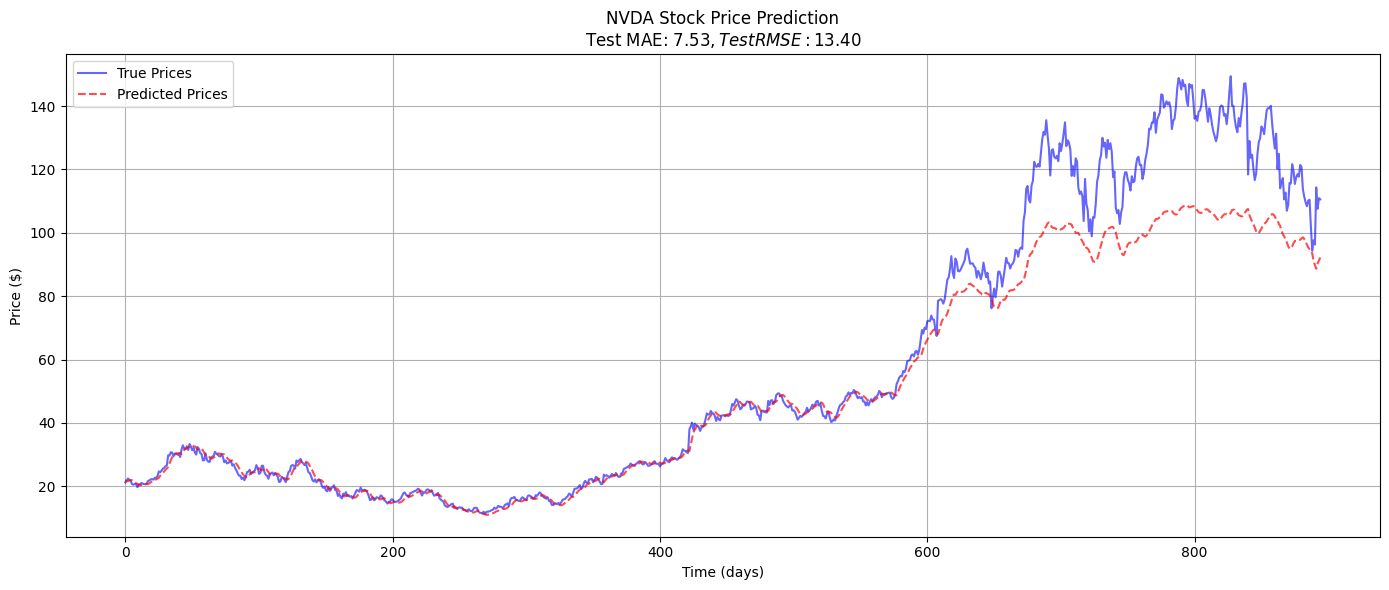


Last 5 Predictions vs Actual:
Day -1: Predicted $92.20 | Actual $110.59
Day -2: Predicted $91.22 | Actual $110.93
Day -3: Predicted $90.27 | Actual $107.57
Day -4: Predicted $88.66 | Actual $114.33
Day -5: Predicted $89.78 | Actual $96.30
Day -6: Predicted $91.22 | Actual $97.64
Day -7: Predicted $93.44 | Actual $94.31
Day -8: Predicted $94.66 | Actual $101.80
Day -9: Predicted $94.90 | Actual $110.42
Day -10: Predicted $95.37 | Actual $110.15


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load the best model
#model.load_state_dict(torch.load("/content/best_model.pth"))
model.load_state_dict(torch.load("/content/drive/MyDrive/FINAL_MODEL.pth", map_location=torch.device('cpu')))

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        preds = model(x_batch).cpu().numpy()
        true = y_batch.cpu().numpy()

        all_preds.append(preds)
        all_true.append(true)

preds = np.concatenate(all_preds)
true = np.concatenate(all_true)

preds = scaler.inverse_transform(preds)
true = scaler.inverse_transform(true)


mae = mean_absolute_error(true, preds)
rmse = np.sqrt(mean_squared_error(true, preds))

print(f"Test MAE: ${mae:.2f}")
print(f"Test RMSE: ${rmse:.2f}")


plt.figure(figsize=(14, 6))
plt.plot(true, label='True Prices', color='blue', alpha=0.6)
plt.plot(preds, label='Predicted Prices', color='red', alpha=0.7, linestyle='--')
plt.title(f'{ticker} Stock Price Prediction\nTest MAE: ${mae:.2f}, Test RMSE: ${rmse:.2f}')
plt.xlabel('Time (days)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)


if len(stock_data) == len(true) + len(X_train) + seq_length:
    dates = stock_data.index[-len(true):]
    plt.xticks(np.linspace(0, len(true)-1, 5),
               dates[np.linspace(0, len(true)-1, 5).astype(int)].strftime('%Y-%m-%d'))

plt.tight_layout()
plt.savefig('stock_prediction.png', dpi=300)
plt.show()


print("\nLast 5 Predictions vs Actual:")
for i in range(1, 11):
    print(f"Day {-i}: Predicted ${preds[-i][0]:.2f} | Actual ${true[-i][0]:.2f}")